In [11]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

In [115]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_mistralai import ChatMistralAI
from langchain_google_genai import ChatGoogleGenerativeAI

In [201]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
# llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)
# llm = ChatMistralAI(model="mistral-small-2603",temperature=0)

In [202]:
print(llm.invoke('hello'))

content='Hello. How can I assist you today?' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.016177886, 'completion_tokens_details': None, 'prompt_time': 0.000960922, 'prompt_tokens_details': None, 'queue_time': 0.056351627, 'total_time': 0.017138808}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e4edd-ec82-7d61-b8a3-3eda746a96de-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46}


In [203]:


from typing import TypedDict, List, Dict
from src.retriever.hybrid_retriever import HybridRetriever,qdrant_client
from src.retriever.reranker import reranker,get_reranked_documents

In [204]:
searcher = HybridRetriever(collection_name="main_vector_store",qdrant_client=qdrant_client)

In [205]:
class RagState(TypedDict):

    query : str 
    retrieved_results :List[Dict]
    reranked_results : List[Dict]
    answer : str 

In [206]:
def retriever_node(RagState):
    query = RagState['query']
    results = searcher.search(query_text=query)

    return {'retrieved_results':results}
    

In [207]:
def reranker_node(RagState):
    query = RagState['query']
    retrieved_results = RagState['retrieved_results']
    reranked_results = get_reranked_documents(query=query,retrieved_results=retrieved_results,top_k=5)
    return {'reranked_results':reranked_results}

In [208]:
def answer_node(RagState): 
    prompt_template = ChatPromptTemplate([
        ("system",
        """
        You are a helpful AI assistant.
        Answer ONLY from the provided context.

        If the answer is not present in the context,
        say:
        'I could not find the answer in the provided document.'

        Always be concise and factual.
        """),
        ("human",
            """
            Context : 
            {context}

            Question : 
            {query}
         """)
    ])
    query = RagState['query']
    context = RagState['reranked_results']
    
    context ="\n".join(
                chunk['document'] for chunk in context
                ) 
    final_prompt = prompt_template.invoke({
        'query':query,
        'context' :context
    })

    response = llm.invoke(final_prompt)
    return {'answer':response.content}



In [ ]:
graph = StateGraph(RagState)

# create nodes
graph.add_node('retriever_node',retriever_node)
graph.add_node('reranker_node',reranker_node)
graph.add_node('answer_node',answer_node)

In [210]:
# create edges 
graph.add_edge(START,'retriever_node')
graph.add_edge('retriever_node','reranker_node')
graph.add_edge('reranker_node','answer_node')
graph.add_edge('answer_node',END)

workflow = graph.compile()

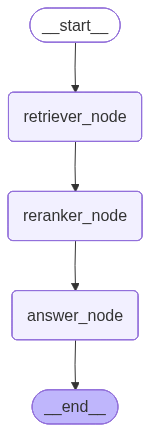

In [211]:
workflow

In [220]:
final_state = workflow.invoke({
    'query':"What are the two outstanding invoices and who is the vendor?"
})

In [221]:
print(final_state['answer'])

The two outstanding invoices are:

1. INV-2024-089 for $78,400
2. INV-2024-156 for $91,600

The vendor for both invoices is NeuralSoft Ltd.


In [15]:
context = [
    {
      "rank": 1,
      "rerank_score": -0.7783107757568359,
      "original_score": 0.2,
      "document": "— in Q2 FY2025 \n• \nComplete Series D funding round of $150 million, targeted for close in March 2025 \n• \nAchieve SOC 2 Type II recertification and begin ISO 42001 (AI Management Systems) \ncertification process \n• \nReduce AWS infrastructure dependency from 74% to below 50% through multi-cloud migration \n• \nGrow headcount to 1,500 employees by end of FY2025 \n \nCEO Statement: In a message to shareholders dated January 20, 2025, NovaTech's CEO stated that the",
      "metadata": {
        "document_id": "3e1c1114-1b33-43b2-b41c-1646ca5e2e7c",
        "file_name": "NovaTech_Annual_Report_FY2024.pdf",
        "page": 4,
        "title": ""
      }
    },
    {
      "rank": 2,
      "rerank_score": -1.0450583696365356,
      "original_score": 0.5,
      "document": "company is positioned to capitalise on the growing enterprise demand for AI-native business intelligence \ntools. The CEO cited customer feedback indicating that AI Insight Engine reduced customers' average \nanalytics cycle time by 67% and decreased the need for external consultants by an estimated $2.1 billion \nin aggregate across the customer base. \n \n7. Regulatory Compliance and Certifications",
      "metadata": {
        "document_id": "3e1c1114-1b33-43b2-b41c-1646ca5e2e7c",
        "file_name": "NovaTech_Annual_Report_FY2024.pdf",
        "page": 4,
        "title": ""
      }
    },
    {
      "rank": 3,
      "rerank_score": -1.0837819576263428,
      "original_score": 0.33333334,
      "document": "NovaTech Solutions — Annual Business Report FY2024   |   CONFIDENTIAL \nNovaTech Solutions Inc.  |  Document ID: NT-RPT-2024-001  |  CONFIDENTIAL \n \n \nNovaTech Solutions Inc. \nAnnual Business Report — Fiscal Year 2024 \nDocument ID: NT-RPT-2024-001  |  Prepared by: Finance & Strategy Division  |  Date: January 31, 2025 \n1. Executive Summary \nNovaTech Solutions Inc. is a B2B software company headquartered in Austin, Texas. The company",
      "metadata": {
        "document_id": "3e1c1114-1b33-43b2-b41c-1646ca5e2e7c",
        "file_name": "NovaTech_Annual_Report_FY2024.pdf",
        "page": 0,
        "title": ""
      }
    }
  ]


In [16]:
context = "\n".join(
    f"""
    Source: {chunk['metadata'].get('file_name')}
    Page: {chunk['metadata'].get('page')}
    Content:
    {chunk['document']}
    """
    for chunk in context
)

In [17]:
print(context)


    Source: NovaTech_Annual_Report_FY2024.pdf
    Page: 4
    Content:
    — in Q2 FY2025 
• 
Complete Series D funding round of $150 million, targeted for close in March 2025 
• 
Achieve SOC 2 Type II recertification and begin ISO 42001 (AI Management Systems) 
certification process 
• 
Reduce AWS infrastructure dependency from 74% to below 50% through multi-cloud migration 
• 
Grow headcount to 1,500 employees by end of FY2025 
 
CEO Statement: In a message to shareholders dated January 20, 2025, NovaTech's CEO stated that the
    

    Source: NovaTech_Annual_Report_FY2024.pdf
    Page: 4
    Content:
    company is positioned to capitalise on the growing enterprise demand for AI-native business intelligence 
tools. The CEO cited customer feedback indicating that AI Insight Engine reduced customers' average 
analytics cycle time by 67% and decreased the need for external consultants by an estimated $2.1 billion 
in aggregate across the customer base. 
 
7. Regulatory Compliance and